# Slide-level QC aggregation check

## Setup

In [1]:
IS_PUBLIC = True  # whether to use public cloud MLFlow
METADATA_CSV_URI = "..."
QC_METRICS_CSV_URI = "..."

In [2]:
import os

import mlflow
import pandas as pd


if IS_PUBLIC:
    os.environ["MLFLOW_TRACKING_USERNAME"] = "..."
    os.environ["MLFLOW_TRACKING_PASSWORD"] = "..."
    mlflow.set_tracking_uri("https://mlflow.rationai.cloud.e-infra.cz/")

metadata = pd.read_csv(mlflow.artifacts.download_artifacts(METADATA_CSV_URI))

/home/jovyan/prostate-cancer/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
slides_to_remove = set()

## File Existance Check

In [5]:
from pathlib import Path


df = pd.read_csv(mlflow.artifacts.download_artifacts(QC_METRICS_CSV_URI))

stems_original = metadata["slide_path"].map(lambda x: Path(x).stem)
stems_present = df["slide_name"]

set(stems_original) - set(stems_present)

{'2cd0af2f881832c9f718c8f435048cd4',
 '8afc7add70b4d06343b2b9f37f58cf65',
 '8b012a7302f32e3f7d03c59473992462',
 '8b421aa81e047f4649df49387c6aad02',
 'ca4796a46bde379a1a364d992fa07217'}

In [6]:
slides_to_remove |= set(stems_original) - set(stems_present)

## Slide Level Mean & Medians

In [7]:
df.columns

Index(['mean_coverage(FoldingFunction)', 'mean_coverage(Piqe)',
       'mean_coverage(ResidualArtifactsAndCoverage)',
       'median_coverage(FoldingFunction)', 'median_coverage(Piqe)',
       'median_coverage(ResidualArtifactsAndCoverage)', 'sample_level',
       'slide_name', 'timestamp'],
      dtype='object')

In [8]:
import matplotlib.pyplot as plt
import numpy as np


def icdf(df: pd.DataFrame, col: str) -> None:
    values = df[col].values
    t = np.linspace(0, 1, 100)
    proportions = [(values > thresh).sum() for thresh in t]

    # plot
    plt.figure()
    plt.plot(t, proportions)
    plt.xlabel("Threshold t")
    plt.ylabel(f"Proportion of {col} > t")
    plt.show()

We remove all slides with median QC coverage at least 0.3.

### Blur

In [9]:
df_blur = df[["slide_name", "median_coverage(Piqe)"]].sort_values(
    by="median_coverage(Piqe)", ascending=False
)
df_blur.head()

,slide_name,median_coverage(Piqe)
4613,da09fe1419dcf0c2e16c0b2a43979c43,1.000000
1674,510375129659a7bf90d2b85b42ce1efd,0.995164
966,2fe01d7bbc55749e8108f0ce9c8fd6ca,0.716538
3832,b4e8ce5eaf3f05ef63de22271519421e,0.676583
2529,799a3e6817e06575c4618ff9e845491a,0.564201


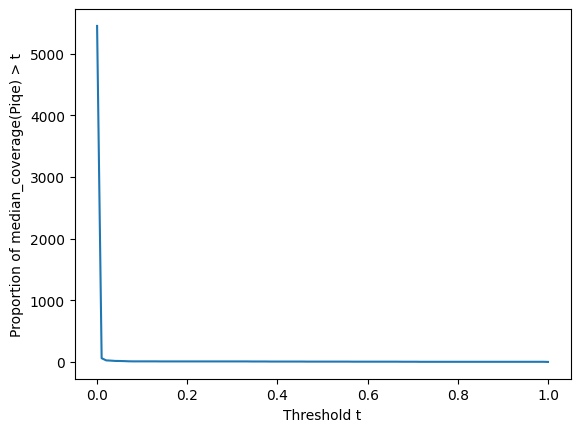

In [10]:
icdf(df, "median_coverage(Piqe)")

In [11]:
for t in [0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]:
    print(len(df[df["median_coverage(Piqe)"] >= t]))

2
2
3
4
5
6
8
8
9


In [12]:
slides_to_remove |= set(df[df["median_coverage(Piqe)"] >= 0.3]["slide_name"])

### Residuals

In [13]:
df_residual = df[
    ["slide_name", "median_coverage(ResidualArtifactsAndCoverage)"]
].sort_values(by="median_coverage(ResidualArtifactsAndCoverage)", ascending=False)
df_residual.head()

,slide_name,median_coverage(ResidualArtifactsAndCoverage)
1588,4d048dd585259614c27e11431ec2c860,0.082417
2102,65ae2ddcf6dbae0f38297cfa1e3e5d0b,0.020426
3637,ac6ac43819c3e01b53b7c63fc4c4c24e,0.000000
3636,ac5f07039fde0b6a831f08d207f9c26c,0.000000
3635,ac46e4ee5b43c383cbea6287ea67c3bb,0.000000


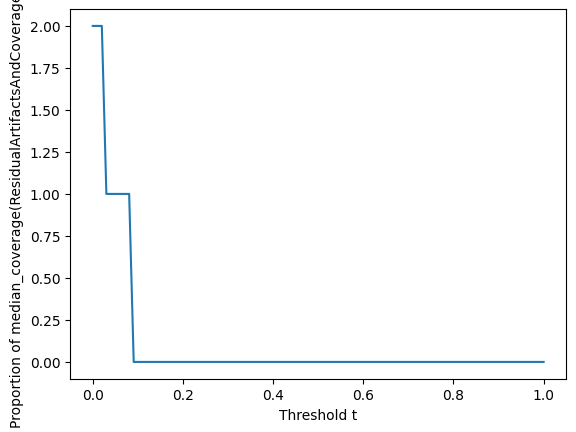

In [14]:
icdf(df, "median_coverage(ResidualArtifactsAndCoverage)")

In [15]:
for t in [0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]:
    print(len(df[df["median_coverage(ResidualArtifactsAndCoverage)"] >= t]))

0
0
0
0
0
0
0
0
0


In [16]:
slides_to_remove |= set(
    df[df["median_coverage(ResidualArtifactsAndCoverage)"] >= 0.3]["slide_name"]
)

### Folding

In [17]:
df_residual = df[["slide_name", "median_coverage(FoldingFunction)"]].sort_values(
    by="median_coverage(FoldingFunction)", ascending=False
)
df_residual.head()

,slide_name,median_coverage(FoldingFunction)
0,0005f7aaab2800f6170c399693a96917,0.0
1,000920ad0b612851f8e01bcc880d9b3d,0.0
2,001c62abd11fa4b57bf7a6c603a11bb9,0.0
3,001d865e65ef5d2579c190a0e0350d8f,0.0
4,002a4db09dad406c85505a00fb6f6144,0.0


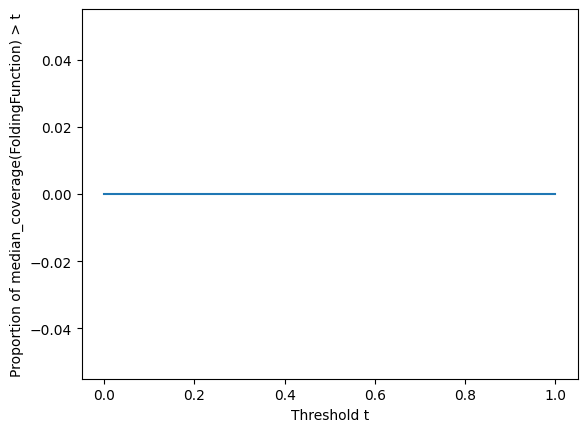

In [18]:
icdf(df, "median_coverage(FoldingFunction)")

In [19]:
for t in [0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]:
    print(len(df[df["median_coverage(FoldingFunction)"] >= t]))

0
0
0
0
0
0
0
0
0


In [20]:
slides_to_remove |= set(df[df["median_coverage(FoldingFunction)"] >= 0.3]["slide_name"])

## Finalze selection

In [21]:
len(slides_to_remove)

13

Store the slides:

In [22]:
pd.DataFrame({"slide_stem": list(slides_to_remove)}).to_csv(
    "to_exclude_based_on_qc.csv", index=False
)

Check what files were removed:

In [23]:
df_excluded = df[df["slide_name"].isin(slides_to_remove)]

In [24]:
df_excluded.head(10)

,mean_coverage(FoldingFunction),mean_coverage(Piqe),mean_coverage(ResidualArtifactsAndCoverage),median_coverage(FoldingFunction),median_coverage(Piqe),median_coverage(ResidualArtifactsAndCoverage),sample_level,slide_name,timestamp
966,0.000000,0.526941,0.000000,0.0,0.716538,0.0,0.0,2fe01d7bbc55749e8108f0ce9c8fd6ca,2026-07-07 02:07:34.245982
1455,0.000374,0.500609,0.000000,0.0,0.457941,0.0,0.0,46fd2b305a7d998540ea08435804e825,2026-07-07 06:07:47.433565
1674,0.000000,0.742605,0.000000,0.0,0.995164,0.0,0.0,510375129659a7bf90d2b85b42ce1efd,2026-07-07 07:59:22.341466
2386,0.000833,0.446527,0.000000,0.0,0.340720,0.0,0.0,738963113c79bb3c8814b06224a263a3,2026-07-07 14:01:01.757174
2529,0.001653,0.497748,0.000000,0.0,0.564201,0.0,0.0,799a3e6817e06575c4618ff9e845491a,2026-07-07 15:14:47.487082
3832,0.008917,0.542071,0.000000,0.0,0.676583,0.0,0.0,b4e8ce5eaf3f05ef63de22271519421e,2026-07-08 01:38:08.485420
4613,0.002121,0.999054,0.001495,0.0,1.000000,0.0,0.0,da09fe1419dcf0c2e16c0b2a43979c43,2026-07-08 07:46:41.240263
4949,0.001268,0.487749,0.000000,0.0,0.383615,0.0,0.0,eaa8d5b00a23d0da9d82b22cf053697d,2026-07-08 10:24:41.830213


In [25]:
assert (
    len(
        df_excluded[
            (df_excluded["median_coverage(ResidualArtifactsAndCoverage)"] < 0.3)
            & (df_excluded["median_coverage(Piqe)"] < 0.3)
            & (df_excluded["median_coverage(FoldingFunction)"] < 0.3)
        ]
    )
    == 0
), "Excluded wrong slides"